# Análise de dados de adesão de arquivos de contexto de IA

## Importando bibliotecas

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


## Carregando dados

In [4]:
DATA_PATH = "../test/context_api_top1000_23-03-2026.csv"

if not os.path.exists(DATA_PATH):
    print(f"ERRO: O arquivo {DATA_PATH} não foi encontrado. Execute o script de detecção primeiro.")
else:
    df = pd.read_csv(DATA_PATH)
    context_columns = [col for col in df.columns if col not in ['name', 'rank']]
    print(f"Dataset carregado: {len(df)} repositórios carregados.")

Dataset carregado: 1000 repositórios carregados.


## Análise dos dados

Distribuição de repositórios com contextos de IA

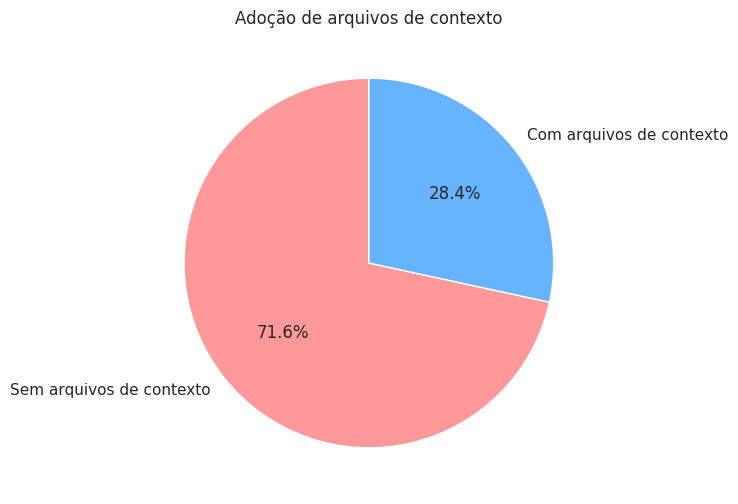

In [5]:
df['has_any_context'] = df[context_columns].any(axis=1)
adoption_counts = df['has_any_context'].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 6))
labels = ['Sem arquivos de contexto', 'Com arquivos de contexto']
plt.pie(adoption_counts, labels=labels, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=90)
plt.title("Adoção de arquivos de contexto")
plt.show()

Distribuição de tipo de arquivo

/tmp/ipykernel_290401/2385448633.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=file_counts.index, y=file_counts.values, palette="viridis")


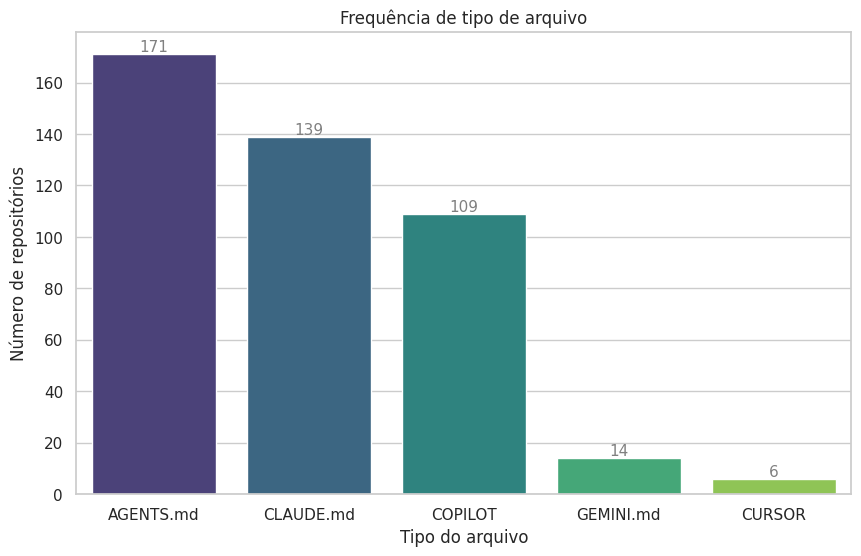

In [6]:
file_counts = df[context_columns].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=file_counts.index, y=file_counts.values, palette="viridis")
plt.title("Frequência de tipo de arquivo")
plt.ylabel("Número de repositórios")
plt.xlabel("Tipo do arquivo")

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=11, color='gray', xytext=(0, 5), 
                textcoords='offset points')

plt.show()

Correlação entre os tipos de arquivo

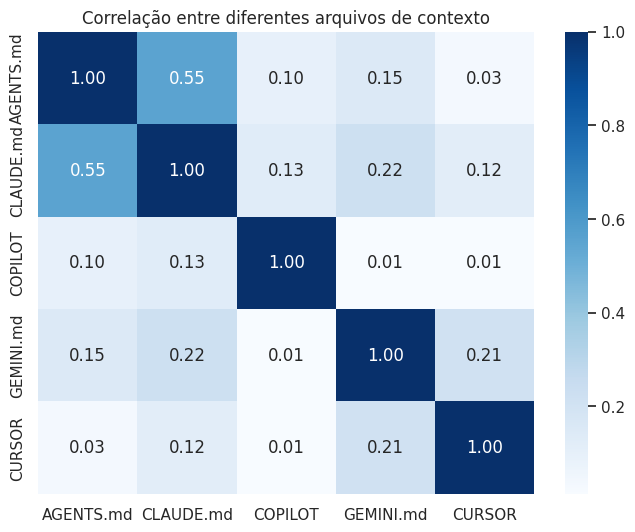

In [7]:
plt.figure(figsize=(8, 6))
correlation_matrix = df[context_columns].corr()
sns.heatmap(correlation_matrix, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlação entre diferentes arquivos de contexto")
plt.show()